In [12]:
# ===========================
# 0. Подключение src/ к ноутбуку
# ===========================
import sys
import os

# Путь к папке src (относительно местоположения ноутбука)
sys.path.append(os.path.abspath('../src'))

# Проверяем, что папка src существует и видны файлы
print(os.listdir('../src'))  # должно вывести ['interface.py', 'random_forest.py', 'feedforward.py', 'cnn.py', 'classifier.py']

# Импортируем обёртку MnistClassifier
from classifier import MnistClassifier

print("Импорт прошёл успешно ✅")


['.ipynb_checkpoints', 'classifier.py', 'cnn.py', 'feedforward.py', 'interface.py', 'random_forest.py', '__pycache__']


ImportError: cannot import name 'FeedForwardMnistClassifier' from 'feedforward' (D:\Users\Greta\Documents\Учеба\PythonProject\Winstars\Test 1\src\feedforward.py)

In [11]:
# ===========================
# 1. Импорты для работы с данными и визуализации
# ===========================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [ ]:
# ===========================
# 2. Загружаем MNIST
# ===========================
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data / 255.0, mnist.target.astype(int)  # нормализация

# Визуально посмотрим на несколько цифр
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X.iloc[i].values.reshape(28,28), cmap='gray')
    plt.title(str(y.iloc[i]))
    plt.axis('off')
plt.show()


In [5]:
# ===========================
# 3. Делим данные на train/test
# ===========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


NameError: name 'train_test_split' is not defined

In [8]:
# ===========================
# 4. Random Forest
# ===========================
clf_rf = MnistClassifier("rf")
clf_rf.train(X_train, y_train)
preds_rf = clf_rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, preds_rf))


Random Forest Accuracy: 0.9672142857142857


In [11]:
# ===========================
# 5. Feed-Forward Neural Network
# ===========================
clf_nn = MnistClassifier("nn")
clf_nn.train(X_train, y_train)  # можно добавить параметр epochs, если есть
preds_nn = clf_nn.predict(X_test)
print("Feed-Forward NN Accuracy:", accuracy_score(y_test, preds_nn))


Feed-Forward NN Accuracy: 0.6778571428571428


In [13]:
# ===========================
# 6. Convolutional Neural Network
# ===========================
# Для CNN нужно изменить форму данных
X_train_cnn = X_train.values.reshape(-1, 28, 28)
X_test_cnn = X_test.values.reshape(-1, 28, 28)

clf_cnn = MnistClassifier("cnn")
clf_cnn.train(X_train_cnn, y_train)
preds_cnn = clf_cnn.predict(X_test_cnn)
print("CNN Accuracy:", accuracy_score(y_test, preds_cnn))


RuntimeError: [enforce fail at alloc_cpu.cpp:121] data. DefaultCPUAllocator: not enough memory: you tried to allocate 5619712000 bytes.

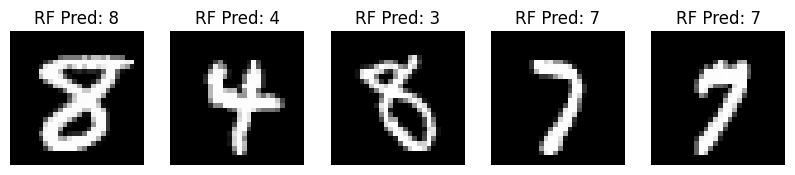

In [19]:
# ===========================
# 7. Визуализация предсказаний (Random Forest)
# ===========================
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test.iloc[i].values.reshape(28,28), cmap='gray')
    plt.title(f"RF Pred: {preds_rf[i]}")  # можно менять на preds_nn или preds_cnn
    plt.axis('off')
plt.show()


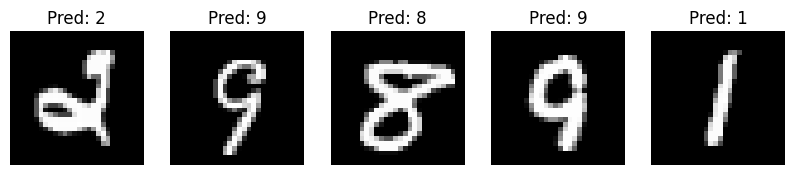

In [23]:
import numpy as np

# Берём случайные 5 индексов из тестовой выборки
indices = np.random.choice(len(X_test), 5, replace=False)

plt.figure(figsize=(10,4))
for i, idx in enumerate(indices):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test.iloc[idx].values.reshape(28,28), cmap='gray')
    plt.title(f"Pred: {preds_rf[idx]}")
    plt.axis('off')
plt.show()
